# Rigid bodies and joints

Two rigid bodies, the first hanging on the ground with a revolute joint about $z$, the second hanging on the first
with a revolute joint about $x$, both under gravity: a double pendulum in 3D. The frames of the bodies are given as
homogeneous transformations, `exu.HT`.

In [1]:
import exudyn as exu
from exudyn.utilities import InertiaCuboid, SensorBody, RotationMatrixX, RotationMatrixY
from exudyn.interactive import ShowImage
import exudyn.graphics as graphics
import numpy as np

SC = exu.SystemContainer()
mbs = SC.AddSystem()

Parameters, and a ground that is drawn as a checkerboard below the pendulum.

In [2]:
g = [0,-9.81,0]     #gravity
L = 1               #length of the bodies
w = 0.1             #width of the bodies

oGround = mbs.CreateGround(graphicsDataList=[graphics.CheckerBoard(point=[0.5,-1.6,0], normal=[0,1,0], size=3)])

The first body: a cuboid of length $L$, whose center of mass is moved by $-L/4$ along its axis - the inertia
class `InertiaCuboid` computes mass, center of mass and inertia tensor, `Translated` moves them. Its reference frame
is at $[L/2, 0, 0]$, without rotation, `exu.HT(translation=...)`. The basis drawn at the center of mass shows where it
is.

In [3]:
iCube0 = InertiaCuboid(density=5000, sideLengths=[L,w,w]).Translated([-0.25*L,0,0])

b0 = mbs.CreateRigidBody(inertia=iCube0,
                         referenceHT=exu.HT(translation=[0.5*L,0,0]),
                         gravity=g,
                         graphicsDataList=[graphics.Brick(size=[L,w,w], color=graphics.color.red),
                                           graphics.Basis(origin=iCube0.com, length=2*w)])

oJoint0 = mbs.CreateRevoluteJoint(bodyNumbers=[oGround, b0], position=[0,0,0], axis=[0,0,1],
                                  axisRadius=0.2*w, axisLength=1.4*w)

The second body hangs at the end of the first and points along $z$: its frame is at $[L, 0, L/2]$; the joint
between the two turns about the global $x$-axis.

In [4]:
b1 = mbs.CreateRigidBody(inertia=InertiaCuboid(density=5000, sideLengths=[w,w,L]),
                         referenceHT=exu.HT(translation=[L,0,0.5*L]),
                         gravity=g,
                         graphicsDataList=[graphics.Brick(size=[w,w,L], color=graphics.color.lightgreen)])

oJoint1 = mbs.CreateRevoluteJoint(bodyNumbers=[b0, b1], position=[L,0,0], axis=[1,0,0],
                                  axisRadius=0.2*w, axisLength=1.4*w)

A force at the tip and a torque on the second body, and a sensor for the position of the tip.

In [5]:
lForce = mbs.CreateForce(bodyNumber=b1, loadVector=[0,0.5,0], localPosition=[0,0,0.5*L])
lTorque = mbs.CreateTorque(bodyNumber=b1, loadVector=[0.1,0,0])

sTip = mbs.AddSensor(SensorBody(bodyNumber=b1, localPosition=[0,0,0.5*L], storeInternal=True,
                                outputVariableType=exu.OutputVariableType.Position))
mbs.Assemble()
dof = mbs.ComputeSystemDegreeOfFreedom()
print('degrees of freedom:', dof['degreeOfFreedom'])

degrees of freedom: 2


The model in its reference configuration, without the nodes and the gravity loads. The view is turned so that
the three axes can be seen.

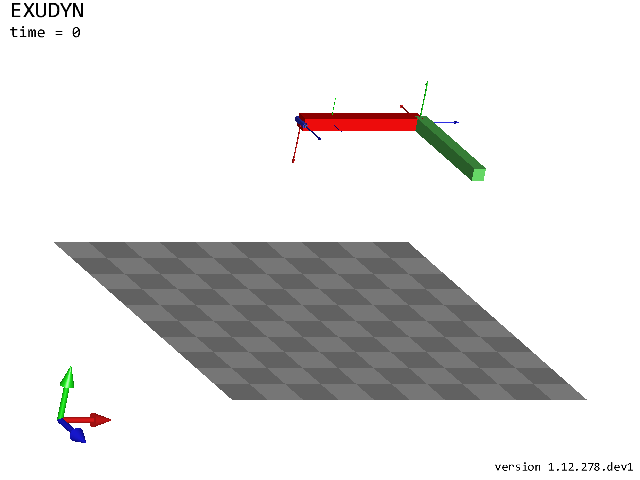

In [6]:
SC.visualizationSettings.nodes.show = False
SC.visualizationSettings.loads.show = False
SC.visualizationSettings.connectors.showJointAxes = True
SC.visualizationSettings.general.showSolverInformation = False
view = RotationMatrixX(-0.4) @ RotationMatrixY(-0.5)
image = ShowImage(SC, size=[640,480], modelRotation=view)

Four seconds with steps of 1 ms. The Euler parameters of the rigid body nodes add one algebraic equation per
body, so the solver is an implicit one, here the index-2 trapezoidal rule.

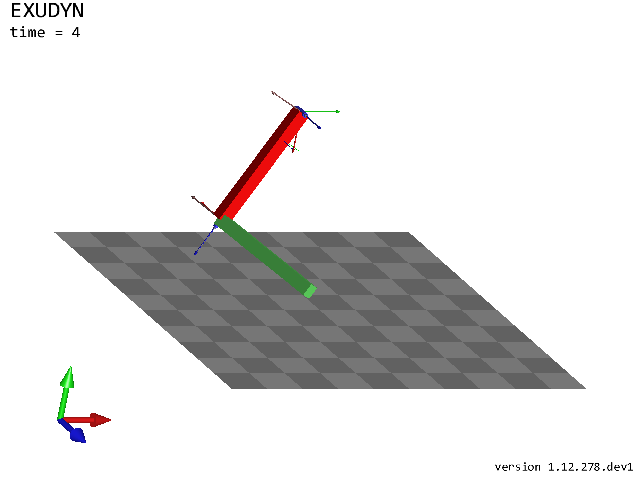

In [7]:
tEnd = 4
h = 1e-3
simulationSettings = exu.SimulationSettings()
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.solution.file.writePeriod = 0.01

mbs.SolveDynamic(simulationSettings, solverType=exu.DynamicSolverType.TrapezoidalIndex2)

image = ShowImage(SC, size=[640,480], modelRotation=view) #the state at the end

The vertical position of the tip over time; the frame of a body at the end, as `exu.HT`:

position of body 1: [-0.329  -0.9634  0.4621]
rotation angle of body 1 (rad): 2.1108


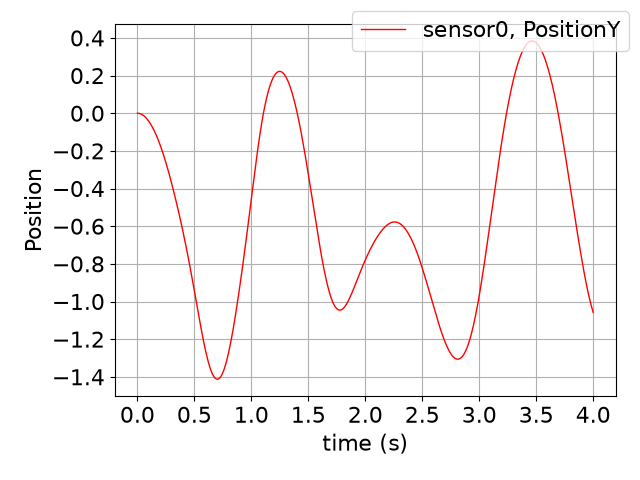

In [8]:
mbs.PlotSensor(sensorNumbers=[sTip], components=[1], closeAll=True)

H = mbs.GetObjectOutputBody(b1, exu.OutputVariableType.HomogeneousTransformation, localPosition=[0,0,0])
print('position of body 1:', np.round(H.translation, 4))
print('rotation angle of body 1 (rad):', round(H.RotationAngle(), 4))

In a script, `mbs.SolutionViewer()` shows the stored motion forward and backward in the render window.